## 0. This checkout, not whatever is installed

`zou_lab_control_v2` is the one entry: importing it puts this checkout's eight layers
on the path, ahead of anything else.  It has to come **first** -- if a `zlc_*` module
was already imported from somewhere else, it refuses out loud rather than leaving two
copies in one kernel.  (If that happens: restart the kernel and run this cell first.)


In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
while not (_here / 'zou_lab_control_v2').is_dir() and _here != _here.parent:
    _here = _here.parent
sys.path.insert(0, str(_here))

import zou_lab_control_v2

print('code in use:', zou_lab_control_v2.ROOT)


code in use: C:\Users\eadri\Dropbox\WorkCode\Github\Zou_lab_control_v2


# 用 workbench 跑一次实验

这个 notebook 教你在**代码里**开机、配脉冲、拍和看。保存显示结果需要 Panel 当时的 signal revision、axis fate、fit 和 overlay,所以由 Task Console 的 Panel Edit 页完成。

GUI 的采集按钮调用同一个 `ExperimentSession`;Panel Save 则直接保存面板正在显示的 exact typed snapshot,不会经过第二套 session 保存 API。


## 1. 工作区

工作区是你这台实验的**自己的东西**:脉冲定义和数据。它不在任何安装的包里,因为脉冲会随实验演化,而库不该跟着改。


In [2]:
from pathlib import Path
from zlc_workbench.session import Workspace

workspace = Workspace(Path.cwd() / "workspace")
print("脉冲定义:", workspace.pulses)
print("数据存这:", workspace.data)

脉冲定义: C:\Users\eadri\Dropbox\WorkCode\Github\Zou_lab_control_v2\packages\zlc_workbench\notebooks\workspace\pulses
数据存这: C:\Users\eadri\Dropbox\WorkCode\Github\Zou_lab_control_v2\packages\zlc_workbench\notebooks\workspace\data


## 2. 开机

`ExperimentSession.open` 从 `apparatus.json` 读出今天实验台上有什么。第一次还没有那个文件,就先用模板起。

**注意 `failures`**:某台设备开不起来不会拖垮整个装置,你会拿到一个能用的相机加一条原因。


In [3]:
from zlc_workbench.session import ExperimentSession

session = ExperimentSession.open(workspace, template="virtual")
print("开不起来的设备:", dict(session.failures) or "无")
print("相机:", type(session.camera).__name__)
print("时序器:", type(session.sequencer).__name__)

开不起来的设备: 无
相机: VirtualCamera
时序器: VirtualSequencer


## 3. 把装置写下来

写下来之后,明天就从文件开机,不用记得今天填了什么。


In [4]:
from zlc_atom.install.configuration import (
    DeviceInstanceConfig, InstallationConfig, save_installation_config,
)

config = InstallationConfig((
    DeviceInstanceConfig("camera", "camera", "camera.virtual", {"seed": 7}),
    DeviceInstanceConfig("sequencer", "sequencer", "sequencer.virtual",
                         {"camera_key": "camera"}),
))
path = save_installation_config(config, workspace.apparatus)
print("装置写到:", path)
print(path.read_text(encoding="utf-8")[:220])

装置写到: C:\Users\eadri\Dropbox\WorkCode\Github\Zou_lab_control_v2\packages\zlc_workbench\notebooks\workspace\apparatus.json
{
  "format": "zlc.installation",
  "devices": [
    {
      "instance_id": "camera",
      "role": "camera",
      "type_id": "camera.virtual",
      "parameters": {
        "seed": 7
      }
    },
    {
      "instanc


## 4. 配脉冲

脉冲自己描述自己:开几个相机窗口、每帧多长、哪一帧是什么。**你不该在别处再写一遍这些数字**——`camera_windows` 就是每发要收的帧数。


In [5]:
pulse = session.load_pulse("calibration")
for key in ("name", "camera_windows", "frame_exposures", "frame_semantics"):
    print(f"{key:18s} {pulse[key]}")

name               calibration


camera_windows     3
frame_exposures    (0.02, 0.005, 0.02)
frame_semantics    ('reference_long_before', 'short_readout', 'reference_long_after')


## 5. 拍一发

采集和点火是**分开的**:相机只管收,谁给它触发是别人的事。这条分工让虚拟和真机走同一条代码。

`session.fire` 每发之间会等 `wait_done`——真板的命令是上升沿检测的,连发不等会被丢掉。


In [6]:
import numpy as np
from zlc_atom.nodes.camera_measurement.measurement import CameraMeasurementNode

node = CameraMeasurementNode(
    camera=session.camera, signal_plane=session.signal_plane, producer="cm",
    repeat=1, frames_per_cycle=int(pulse["camera_windows"]),
)

capture = node.prepare()
session.fire(shots=1)
result = capture.collect()

snapshot = result.publication.value(node.signal_key("frames")).snapshot
frames = np.asarray(snapshot.block.values)
print("一发拿到的数据块:", frames.shape, "(repeat, point, 帧, y, x)")

一发拿到的数据块: (1, 1, 3, 32, 48) (repeat, point, 帧, y, x)


## 6. 再拍两发

同一个节点可以反复用。每发拿到新的 generation 和递增的 revision,这是面板能更新的前提。


In [7]:
for shot in range(2):
    capture = node.prepare()
    session.fire(shots=1)
    snap = capture.collect().publication.value(node.signal_key("frames")).snapshot
    print(f"第 {shot + 2} 发  revision={snap.ref.revision.value}  "
          f"generation={snap.ref.stream_generation.value}")

第 2 发  revision=2  generation=cm.7acf59c3401a4df4849207ccb3dfda2f
第 3 发  revision=3  generation=cm.500a1a1191d74d1f80139bcdc1c4cf31


## 7. 看

`zlc_plot` 拿的就是刚才那个 snapshot。同一个 session 每拍一发,把新的喂给它就行。


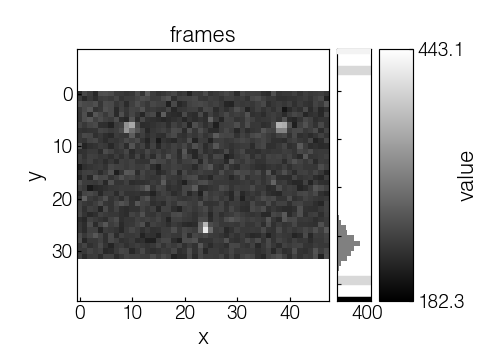

In [8]:
import zlc_plot as plot

view = plot.image(
    snapshot,
    plot.AxisRef.data("spatial-x"),
    plot.AxisRef.data("spatial-y"),
    labels=plot.PlotLabels("frames", "x", "y"),
)
plot.show(view)

## 8. 存

正式保存入口在 Task Console 的 Panel Edit 页。只有 Panel 知道此刻画的是哪个 signal revision、axis fate、fit 和 overlay,所以 `ExperimentSession` 不另设一条缺少这些信息的保存路径。

在 Edit 页点 **Save**,选择 PNG、PDF 或 SVG 文件名。Workbench 会先写同名 `.npz` archive,再渲染图片:archive 失败时不生成图片;图片失败时错误会明确告诉你已经保存好的 archive 在哪里。

`.npz` 保存 typed snapshot、panel state 和 run chain,Figure Viewer 可以直接重新打开。图片只是这份数据在当时显示设置下的派生结果。


## 9. 取回来

把 Panel Save 生成的 `.npz` 交给 Figure Viewer 即可恢复数据和画图选择。archive 本身仍可用 numpy 和标准库读取,不依赖保存它的 Workbench 进程。


## 10. 收工

关掉 session 会关掉所有设备并释放信号面。


In [11]:
session.close()
print("已关闭")

已关闭


---

## 这些方法,GUI 里是哪个按钮

| 这里 | 窗口里 |
|---|---|
| `ExperimentSession.open` | 启动时读装置 |
| `save_installation_config` | 设备管理器的 Save |
| `session.load_pulse` | 选脉冲 |
| `node.prepare` / `session.fire` | Start |
| `plot.image` | Add Panel |
| Panel Edit 中选择文件名 | Save |

采集由 session 拥有,保存由正在显示 exact snapshot 的 Panel 拥有;两者共享同一份 typed data,不维护两套保存实现。
